# 📊 Projeto: Análise de Desenvolvedores - StackOverflow

## 📃 1. Introdução
Importando os principais pacotes e analisando a estrutura do dataframe

In [2]:
# Importação dos pacotes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Criação do Dataframe Principal
df = pd.read_csv("survey_data.csv")

In [4]:
# Analisando as 5 primeiras linhas
df.head(3)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN


In [5]:
# Analisando a estrutura do Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65457 entries, 0 to 65456
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


## 🧹 2. Limpeza de dados
Remoção de valores nulos, inconsistências e padronização para melhorar as análises

In [7]:
# Filtrando e entendendo as colunas com valores duplicados
df.apply(lambda col: col.duplicated().sum())

ResponseId                20
MainBranch             65452
Age                    65449
Employment             65347
RemoteWork             65453
                       ...  
JobSatPoints_11        65377
SurveyLength           65453
SurveyEase             65453
ConvertedCompYearly    59343
JobSat                 65445
Length: 114, dtype: int64

In [8]:
# Após perceber que a coluna ResponseId não pode possuir valores duplicados, iremos remover todos dessa coluna
df.drop_duplicates(subset=['ResponseId'], inplace=True)

In [10]:
# Trantando a coluna Employment para remover inconsistências
trabalha = df['Employment'].str.contains('Employed', na=False)
nao_trabalha = df['Employment'].str.contains('Not employed', na=False)

df = df[~(trabalha & nao_trabalha)] # Remove os registros que possuem trabalha e não trabalho ao mesmo tempo
df = df[df['Employment'] != 'Retired'] # Remove quem é aposentado

In [11]:
# Removendo valores quebrados na coluna Anos de experiência para facilitar a análise
df["YearsCodePro"] = df["YearsCodePro"].replace(
    "Less than 1 year",
    1
)
df["YearsCodePro"] = df["YearsCodePro"].replace(
    "More than 50 years",
    50
)

df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce') # Transformando ela em tipo numérico

In [12]:
# Alterando a coluna de idade para valores numéricos
map_idades = {
    'Under 18 years old': 15,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70,
    '18-24 years old': 23
}
df['Age'] = df['Age'].replace(map_idades)
df = df[df['Age'] != 'Prefer not to say']

# 📊 3. Análise exploratória dos principais dados

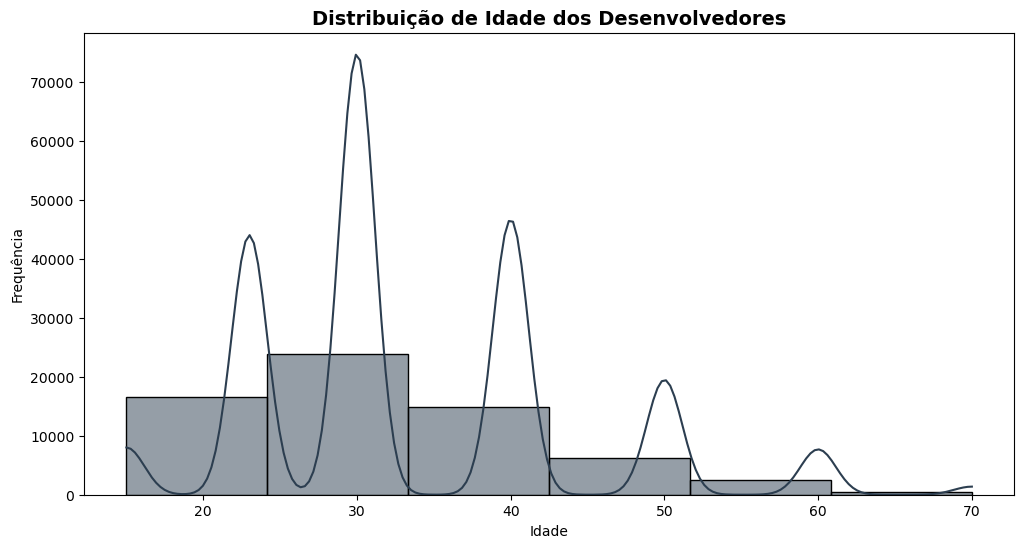

In [13]:
# Analisando a distribuição de idade dos desenvolvedores

# Plotagem do gráfico
plt.figure(figsize=(12,6))
sns.histplot(df['Age'], bins=6, kde=True, color='#2c3e50')
plt.title('Distribuição de Idade dos Desenvolvedores', fontsize=14, weight='bold')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

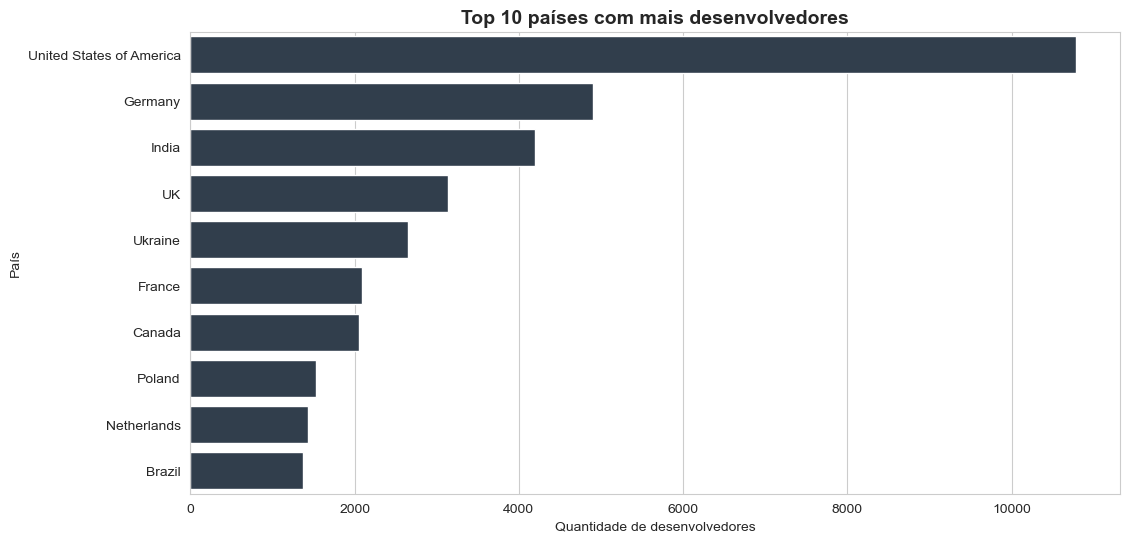

In [42]:
# Analisando os 10 países com desenvolvedores

# Substituindo o nome do País UK para melhorar a vizualização
df['Country'] = df['Country'].replace({
    'United Kingdom of Great Britain and Northern Ireland': 'UK'
})

# Coletando os 10 países com mais Devs.
top10_countries = df['Country'].value_counts().head(10)

# Plotagem do gráfico
plt.figure(figsize=(12,6))
sns.barplot(x=top10_countries.values, y=top10_countries.index, color='#2c3e50')
plt.title("Top 10 países com mais desenvolvedores", fontsize=14, weight='bold')
plt.xlabel("Quantidade de desenvolvedores")
plt.ylabel("País")
plt.show()

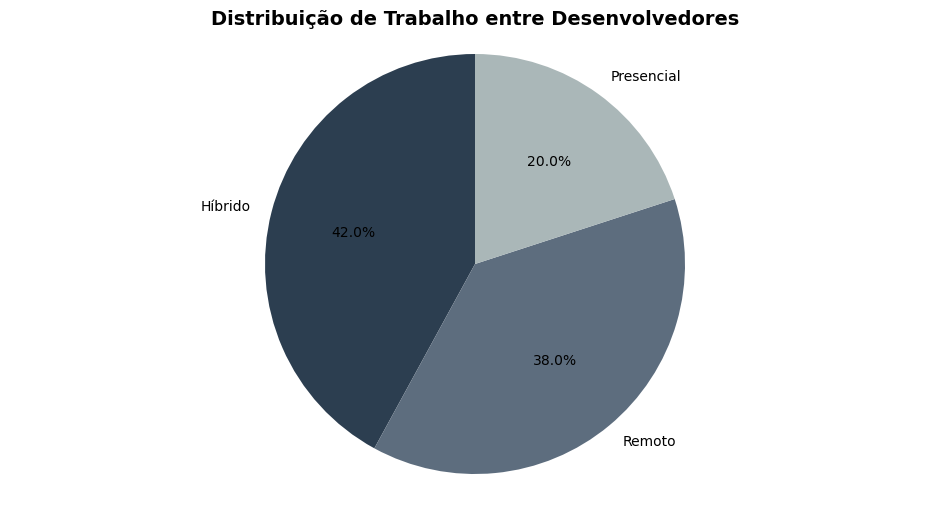

In [15]:
# Analisando a distribuição de modelo de trabalho (Presencial, Home Office e Híbrido)

# Distribuição dos modelos de trabalhos
remote_counts = df['RemoteWork'].value_counts()

# Trocando os nomes para o Português-BR
labels_map = {
    'Remote': 'Remoto',
    'In-person': 'Presencial',
    'Hybrid (some remote, some in-person)': 'Híbrido'
}

# Plotagem do gráfico
labels = [labels_map[i] for i in remote_counts.index]
colors = ['#2c3e50', '#5d6d7e', '#aab7b8']
plt.figure(figsize=(12,6))
plt.pie(
    remote_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'color': 'black'}
)
plt.title('Distribuição de Trabalho entre Desenvolvedores', fontsize=14, weight='bold')
plt.axis('equal')
plt.show()

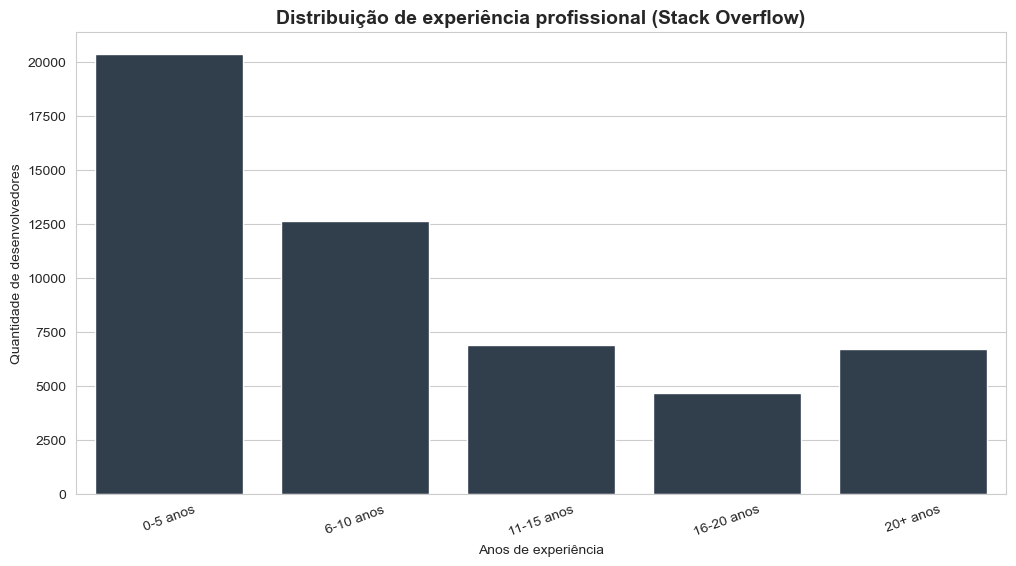

In [43]:
# Analisando a quantidade de desenvolvedores por anos de experiência

# Definindo as faixas de idade
bins = [0, 5, 10, 15, 20, 100]
labels = ['0-5 anos', '6-10 anos', '11-15 anos', '16-20 anos', '20+ anos']

# Criando a coluna de faixa
df['faixa_experiencia'] = pd.cut(
    df['YearsCodePro'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Plotagem do gráfico
plt.figure(figsize=(12,6))
sns.countplot(
    x='faixa_experiencia',
    data=df,
    order=labels,
    color='#2c3e50'
)
plt.title("Distribuição de experiência profissional (Stack Overflow)", fontsize=14, weight='bold')
plt.xlabel("Anos de experiência")
plt.ylabel("Quantidade de desenvolvedores")
plt.xticks(rotation=20)
plt.show()

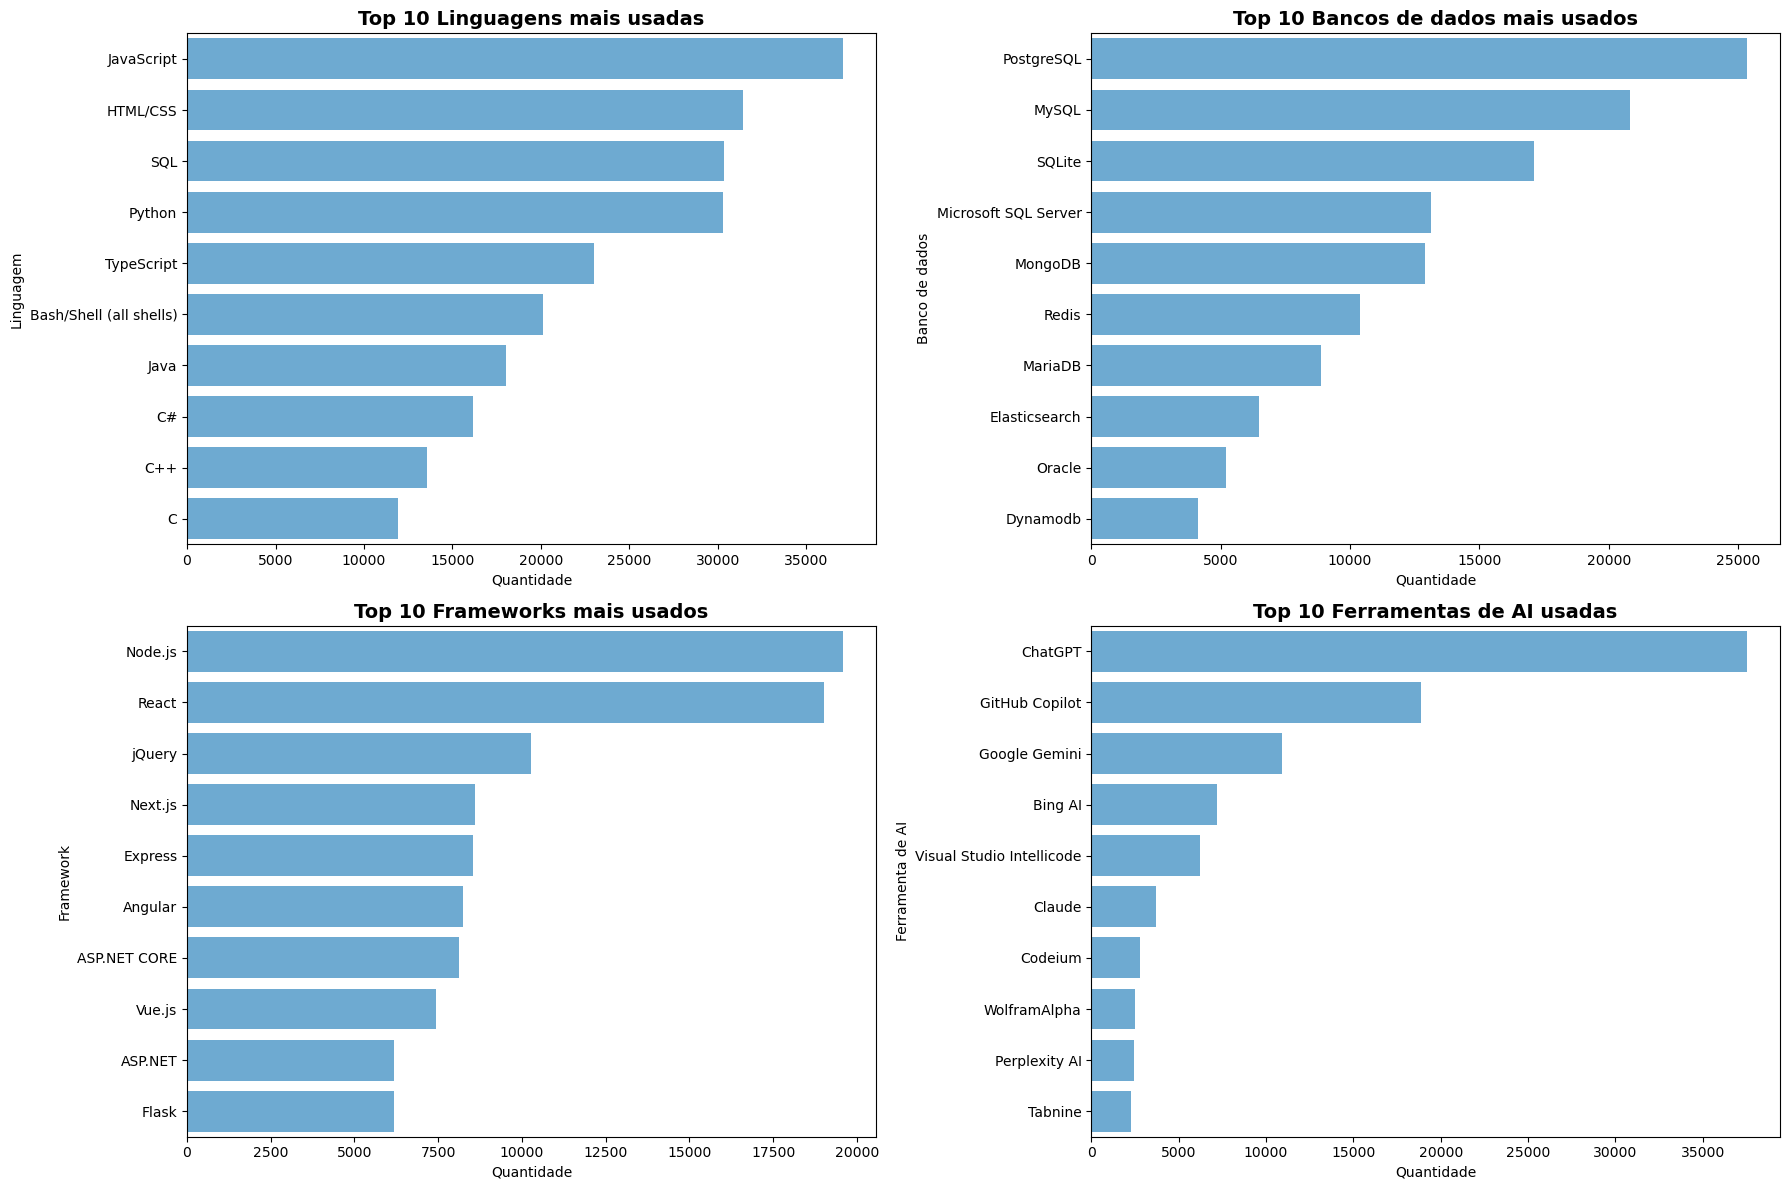

In [17]:
# Analisando as tecnologias mais utilizadas no dia a dia dos desenvolvedores

# Função para puxar a top 10 tecnologias mais utilizadas
def top_tecnologias_trabalhadas(coluna, top_n=10):
    return (
        df[coluna]
        .dropna()
        .str.split(';')
        .explode()
        .value_counts()
        .head(top_n)
    )

# Escolhendo as colunas com os principais tipos de tecnologia
langs = top_tecnologias_trabalhadas('LanguageHaveWorkedWith') # Linguagens de programação
dbs = top_tecnologias_trabalhadas('DatabaseHaveWorkedWith') # Banco de dados
frameworks = top_tecnologias_trabalhadas('WebframeHaveWorkedWith') # Framework
ai_tools = top_tecnologias_trabalhadas('AISearchDevHaveWorkedWith') # IA

# Plotando os 4 gráficos com cada uma das tecnologias
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(x=langs.values, y=langs.index, ax=axes[0, 0], color='#5dade2')
axes[0, 0].set_title('Top 10 Linguagens mais usadas', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Quantidade')
axes[0, 0].set_ylabel('Linguagem')

sns.barplot(x=dbs.values, y=dbs.index, ax=axes[0, 1], color='#5dade2')
axes[0, 1].set_title('Top 10 Bancos de dados mais usados', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('Quantidade')
axes[0, 1].set_ylabel('Banco de dados')

sns.barplot(x=frameworks.values, y=frameworks.index, ax=axes[1, 0], color='#5dade2')
axes[1, 0].set_title('Top 10 Frameworks mais usados', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Quantidade')
axes[1, 0].set_ylabel('Framework')

sns.barplot(x=ai_tools.values, y=ai_tools.index, ax=axes[1, 1], color='#5dade2')
axes[1, 1].set_title('Top 10 Ferramentas de AI usadas', fontsize=14, weight='bold')
axes[1, 1].set_xlabel('Quantidade')
axes[1, 1].set_ylabel('Ferramenta de AI')

plt.tight_layout()
plt.show()

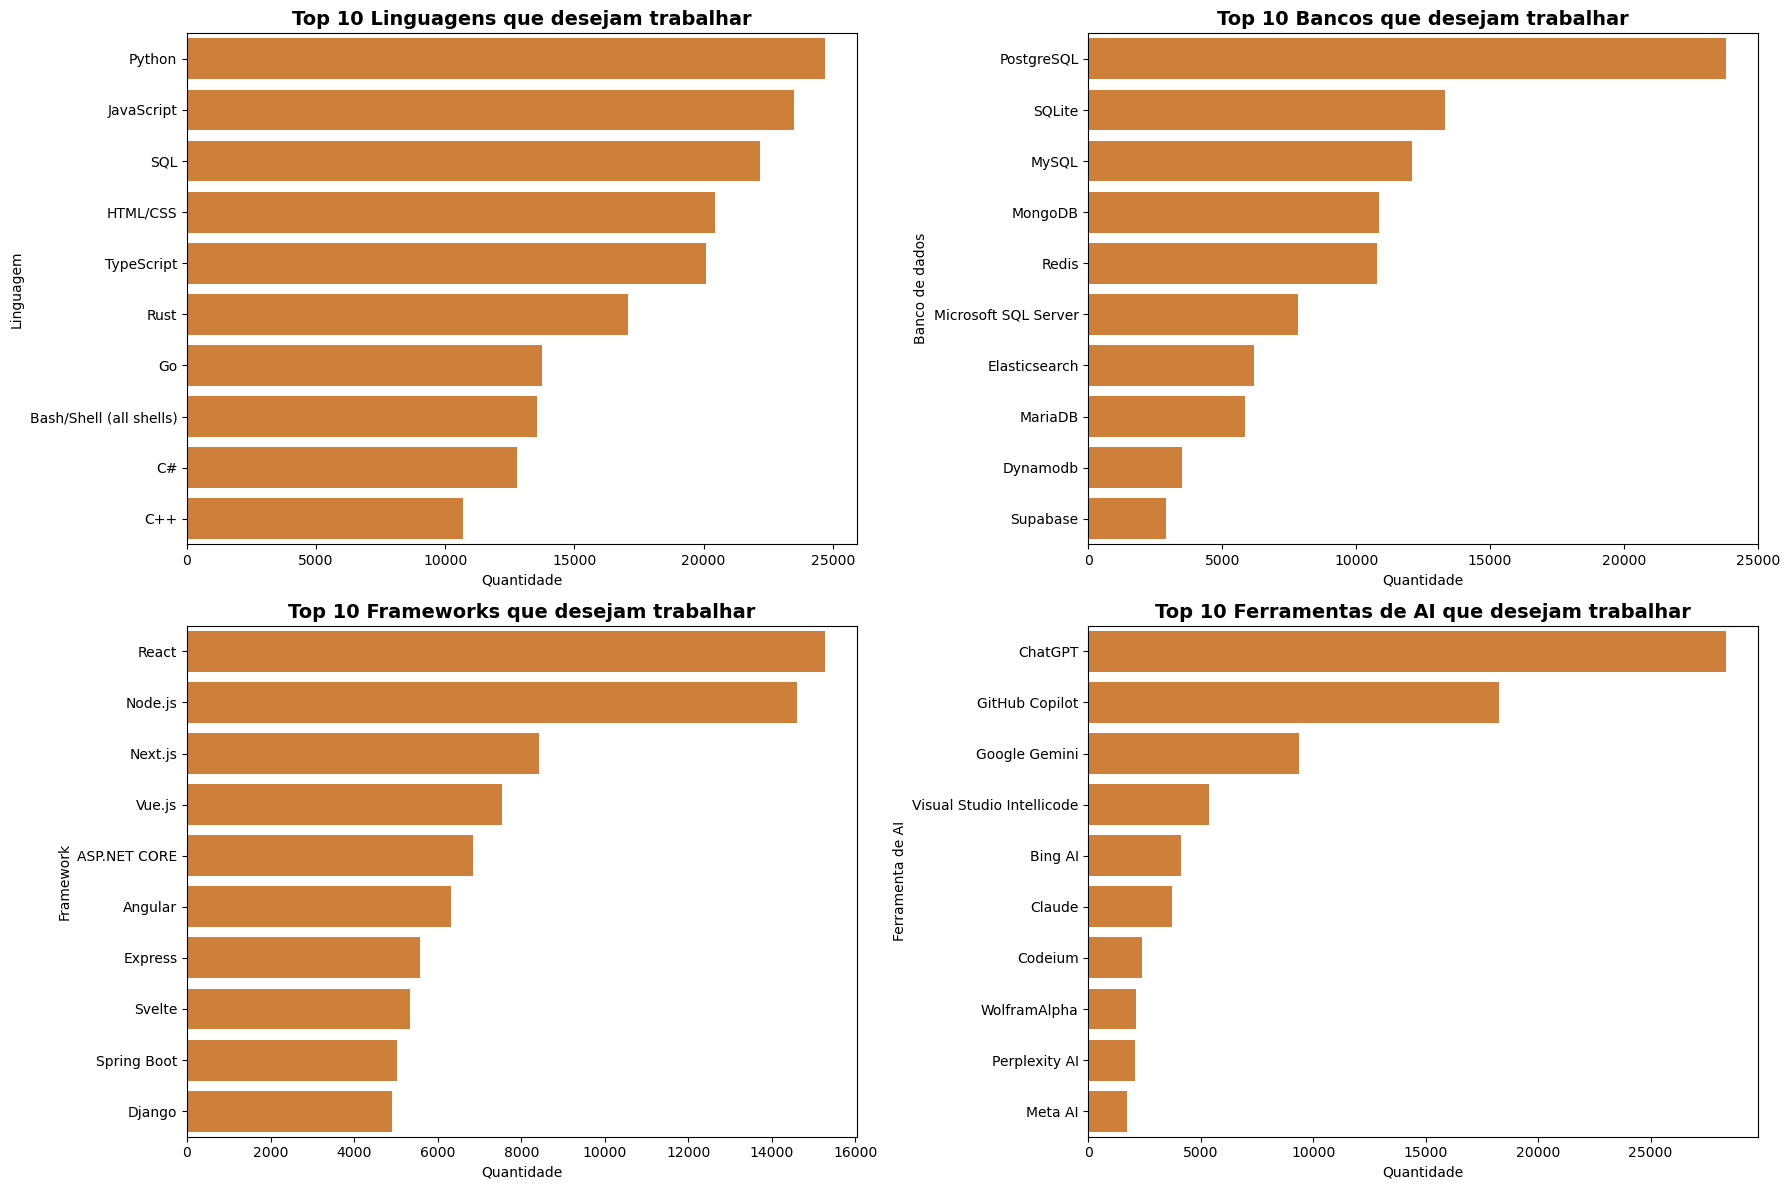

In [18]:
# Analisando as principais tecnologias que os Desenvolvedores querem trabalhar no futuro

# Função para puxar a top 10 tecnologias mais desejadas
def top_tecnologias_desejadas(coluna, top_n=10):
    return (
        df[coluna]
        .dropna()
        .str.split(';')
        .explode()
        .value_counts()
        .head(top_n)
    )

# Escolhendo as colunas com os principais tipos de tecnologia
langs = top_tecnologias_trabalhadas('LanguageWantToWorkWith') # Linguagens de programação
dbs = top_tecnologias_trabalhadas('DatabaseWantToWorkWith') # Banco de dados
frameworks = top_tecnologias_trabalhadas('WebframeWantToWorkWith') # Frameworks
ai_tools = top_tecnologias_trabalhadas('AISearchDevWantToWorkWith') # IA

# Plotando os gráficos
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(x=langs.values, y=langs.index, ax=axes[0, 0], color='#e67e22')
axes[0, 0].set_title('Top 10 Linguagens que desejam trabalhar', fontsize=14, weight='bold')
axes[0, 0].set_xlabel('Quantidade')
axes[0, 0].set_ylabel('Linguagem')

sns.barplot(x=dbs.values, y=dbs.index, ax=axes[0, 1], color='#e67e22')
axes[0, 1].set_title('Top 10 Bancos que desejam trabalhar', fontsize=14, weight='bold')
axes[0, 1].set_xlabel('Quantidade')
axes[0, 1].set_ylabel('Banco de dados')

sns.barplot(x=frameworks.values, y=frameworks.index, ax=axes[1, 0], color='#e67e22')
axes[1, 0].set_title('Top 10 Frameworks que desejam trabalhar', fontsize=14, weight='bold')
axes[1, 0].set_xlabel('Quantidade')
axes[1, 0].set_ylabel('Framework')

sns.barplot(x=ai_tools.values, y=ai_tools.index, ax=axes[1, 1], color='#e67e22')
axes[1, 1].set_title('Top 10 Ferramentas de AI que desejam trabalhar', fontsize=14, weight='bold')
axes[1, 1].set_xlabel('Quantidade')
axes[1, 1].set_ylabel('Ferramenta de AI')

plt.tight_layout()
plt.show()

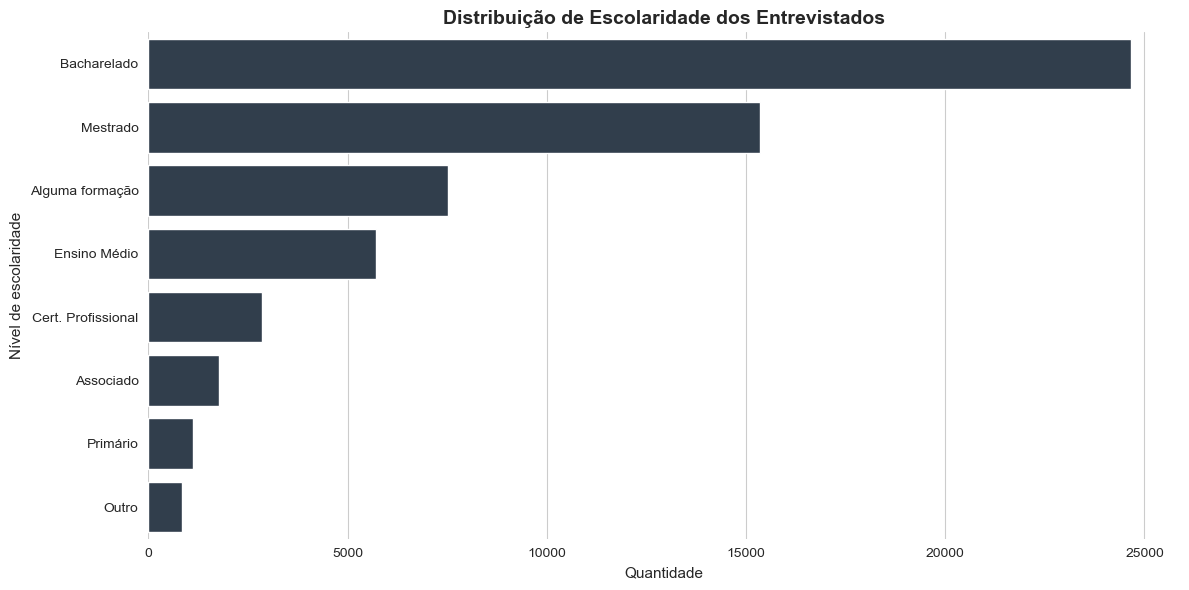

In [19]:
# Analisando a escolaridade dos Desenvolvedores entrevistados

# Renomeando as colunas para melhorar a vizualização do gráfico
counts = df['EdLevel'].value_counts()
counts_renamed = counts.rename({
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bacharelado",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Mestrado",
    "Some college/university study without earning a degree": "Alguma formação",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Ensino Médio",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Cert. Profissional",
    "Associate degree (A.A., A.S., etc.)": "Associado",
    "Primary/elementary school": "Primário",
    "Something else": "Outro"
})

# Transformando os dados em Datraframe para importar no Seaborn
df_escolaridade = counts_renamed.reset_index()
df_escolaridade.columns = ['Escolaridade', 'Quantidade']

# Plotagem do gráfico
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_escolaridade,
    y='Escolaridade',
    x='Quantidade',
    color='#2c3e50'
)
plt.title('Distribuição de Escolaridade dos Entrevistados', fontsize=14, weight='bold')
plt.xlabel('Quantidade', fontsize=11)
plt.ylabel('Nível de escolaridade', fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

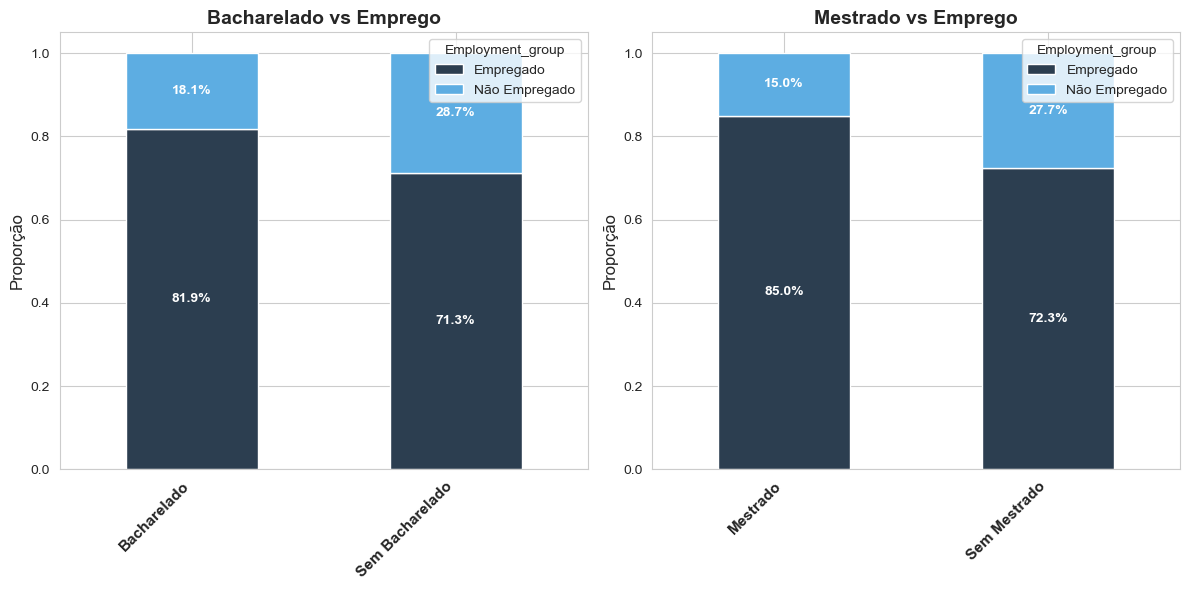

In [44]:
# Analisando se a escolaridade é um requisito fundamental para estar trabalhando na área

# Criando uma coluna apenas com as pessoas que possuem Bacharelado
df['EdLevel_group'] = df['EdLevel'].apply(
    lambda x: 'Bacharelado' if 'Bachelor' in str(x) else 'Sem Bacharelado'
)

# Criando uma coluna apenas com as pessoas que estão trabalhando
df['Employment_group'] = df['Employment'].apply(
    lambda x: 'Empregado' if 'Employed' in str(x) else 'Não Empregado'
)

# Criando uma coluna apenas com as pessoas que possuem mestrado
df['EdLevel_master'] = df['EdLevel'].apply(
    lambda x: 'Mestrado' if 'Master' in str(x) else 'Sem Mestrado'
)

# Criação da matriz de comparação
ct_employment_bachelor = pd.crosstab(df['EdLevel_group'], df['Employment_group'], normalize='index')
ct_employment_master = pd.crosstab(df['EdLevel_master'], df['Employment_group'], normalize='index')

# Plotagem dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico - Bacharelado vs Empregados
ct_employment_bachelor.plot(kind='bar', stacked=True, ax=axes[0], color=['#2c3e50', '#5dade2'])
axes[0].set_title('Bacharelado vs Emprego', fontsize=14, weight='bold')
axes[0].set_ylabel('Proporção', fontsize=12)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelsize=11, labelrotation=45)
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontweight='bold', ha='right')

# Gráfico - Mestrado vs Empregados
ct_employment_master.plot(kind='bar', stacked=True, ax=axes[1], color=['#2c3e50', '#5dade2'])
axes[1].set_title('Mestrado vs Emprego', fontsize=14, weight='bold')
axes[1].set_ylabel('Proporção', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', labelsize=11, labelrotation=45)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontweight='bold', ha='right')

# Adicionando porcentagens dentro das barras
for ax in axes:
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()

        if height > 0:
            x = p.get_x() + width / 2
            y = p.get_y() + height / 2

            cor_texto = 'white' if height > 0.15 else 'white'

            ax.text(
                x, y,
                f'{height*100:.1f}%',
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color=cor_texto
            )

plt.tight_layout()
plt.show()

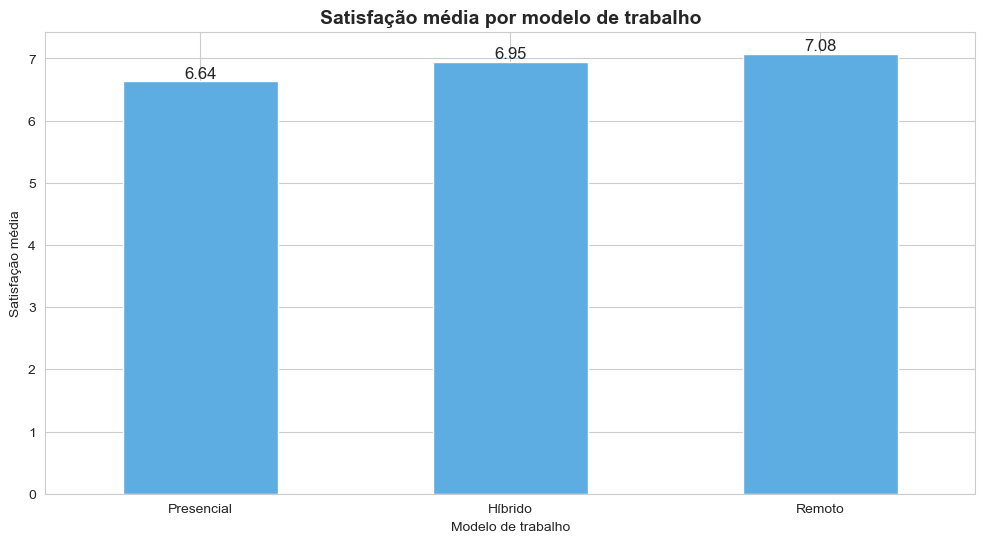

In [23]:
# Analisando a Satisfação por modelo de trabalho

# Filtrando valores não nulos
df_remote_jobsat = df[['RemoteWork', 'JobSat']].dropna()

# Agrupando as colunas de remoto e satisfação no trabalho
media_remote_jobsat = df_remote_jobsat.groupby('RemoteWork')['JobSat'].mean().sort_values()
media_remote_jobsat = media_remote_jobsat.rename({
    'In-person': 'Presencial',
    'Hybrid (some remote, some in-person)': 'Híbrido',
    'Remote': 'Remoto'
})

# Plotagem do gráfico
plt.figure(figsize=(12,6))
ax = media_remote_jobsat.plot(kind='bar', color='#5dade2')
plt.title('Satisfação média por modelo de trabalho', fontsize=14, weight='bold')
plt.ylabel('Satisfação média')
plt.xlabel('Modelo de trabalho')
for i, v in enumerate(media_remote_jobsat):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=12)
plt.xticks(rotation=0)
plt.show()

## 💰 Análise de remuneração com as principais colunas do Dataframe

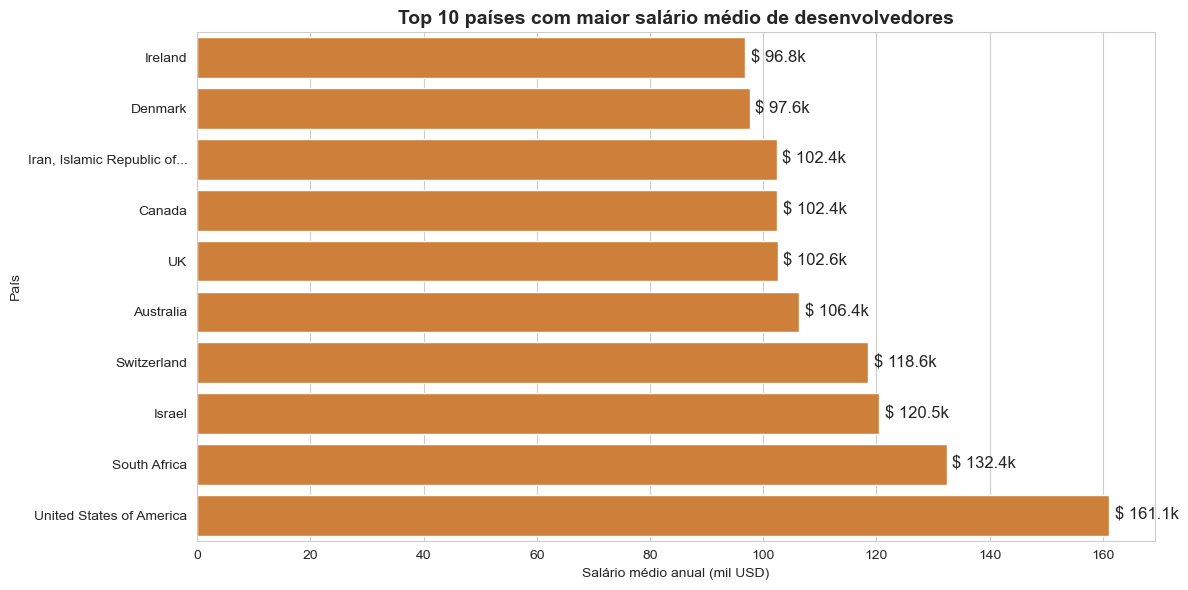

In [24]:
# Analisando os países com a maior remuneração média

# Filtragem dos principais paises
salary_data = df[['Country', 'ConvertedCompYearly']].dropna()
country_counts = salary_data['Country'].value_counts()
valid_countries = country_counts[country_counts >= 100].index
salary_country = (
    salary_data[salary_data['Country'].isin(valid_countries)]
    .groupby('Country')['ConvertedCompYearly']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True) / 1000
)

# Trocando o nome do UK para melhorar a vizualização
salary_country.index = salary_country.index.str.replace(
    'United Kingdom of Great Britain and Northern Ireland',
    'United Kingdom'
)

# Plotagem do gráfico
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=salary_country.values,
    y=salary_country.index,
    color='#e67e22'
)
for i, v in enumerate(salary_country.values):
    ax.text(v + 1, i, f'$ {v:.1f}k', va='center', fontsize=12)
plt.title("Top 10 países com maior salário médio de desenvolvedores", fontsize=14, weight='bold')
plt.xlabel("Salário médio anual (mil USD)")
plt.ylabel("País")
plt.tight_layout()
plt.show()

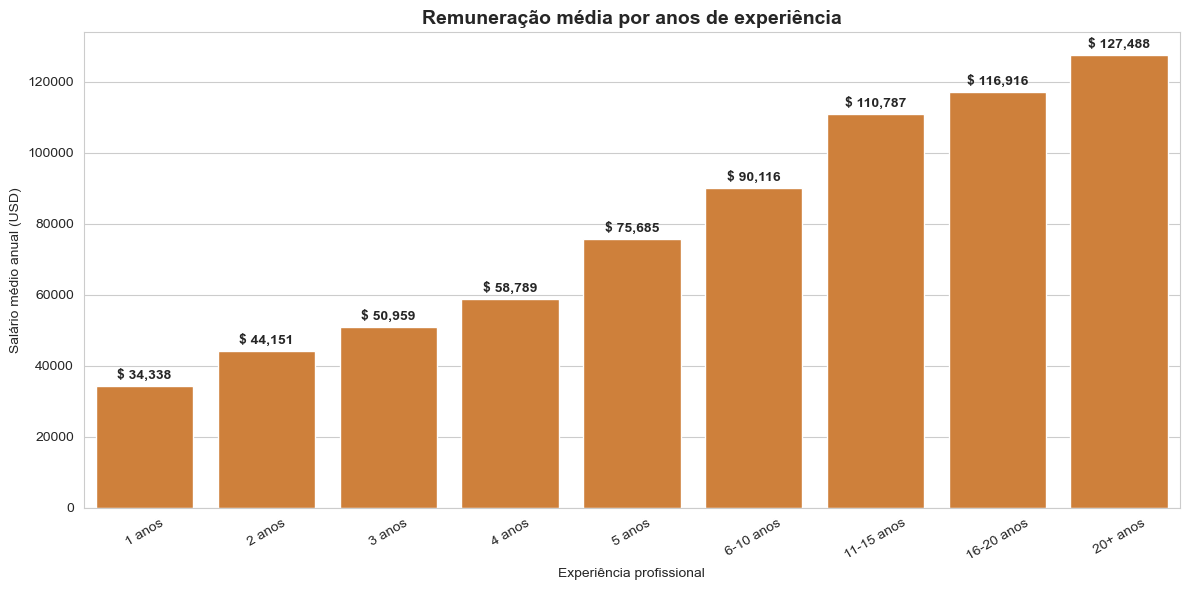

In [41]:
# Analisando a remuneração média por anos de experiência

# Selecionando as colunas necessárias para análise e as transformando em tipo numérico
exp_salary = df[['YearsCodePro', 'ConvertedCompYearly']].dropna().copy()
exp_salary['YearsCodePro'] = pd.to_numeric(exp_salary['YearsCodePro'], errors='coerce')

# Função para criar as faixas de tempo de experiência
def faixa_experiencia(x):
    if x <= 5:
        return f"{int(x)} anos"
    elif x <= 10:
        return "6-10 anos"
    elif x <= 15:
        return "11-15 anos"
    elif x <= 20:
        return "16-20 anos"
    else:
        return "20+ anos"

exp_salary['faixa_exp'] = exp_salary['YearsCodePro'].apply(faixa_experiencia)

# Definindo a ordem para aparecer as idades no gráfico
ordem = [
    '0 anos','1 anos','2 anos','3 anos','4 anos','5 anos',
    '6-10 anos','11-15 anos','16-20 anos','20+ anos'
]

# Calculando a média salarial
salary_exp = (
    exp_salary.groupby('faixa_exp')['ConvertedCompYearly']
    .mean()
    .reindex(ordem)
    .dropna()
)

# Plotagem do gráfico
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=salary_exp.index,
    y=salary_exp.values,
    color='#e67e22'
)

# Inserir valores acima das barras
for i, v in enumerate(salary_exp.values):
    ax.text(i, v + 2000, f'$ {v:,.0f}', ha='center', weight='bold')

plt.title("Remuneração média por anos de experiência", fontsize=14, weight='bold')
plt.xlabel("Experiência profissional")
plt.ylabel("Salário médio anual (USD)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

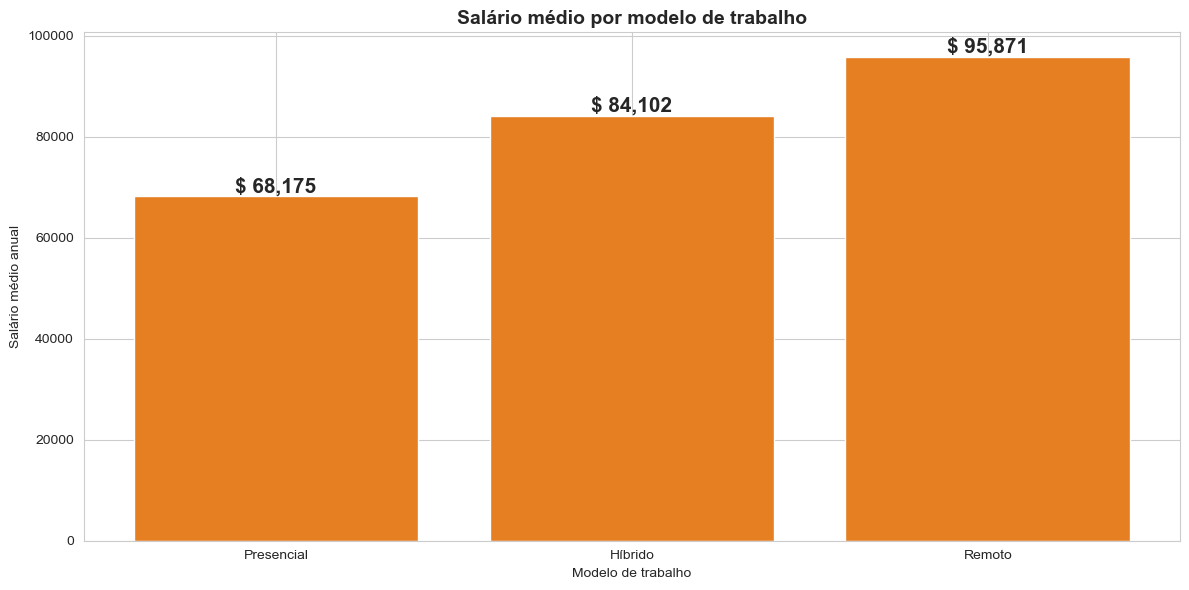

In [35]:
# Analisando a remuneração média por modelo de trabalho

# Agrupando as colunas de remuneração e modelo de trabalho
salary_by_work = df.groupby("RemoteWork")["ConvertedCompYearly"].mean().sort_values()

# Renomear as colunas
labels = {
    "Remote": "Remoto",
    "In-person": "Presencial",
    "Hybrid (some remote, some in-person)": "Híbrido"
}
salary_by_work = salary_by_work.rename(index=labels)

# Plotagem do gráfico
plt.figure(figsize=(12,6))
bars = plt.bar(
    salary_by_work.index,
    salary_by_work.values,
    color="#e67e22"
)
plt.title("Salário médio por modelo de trabalho", fontsize=14, weight='bold')
plt.xlabel("Modelo de trabalho")
plt.ylabel("Salário médio anual")

# Inserir valores em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"$ {height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=15,
        weight='bold'
    )
# Exibindo o gráfico
plt.tight_layout()
plt.show()

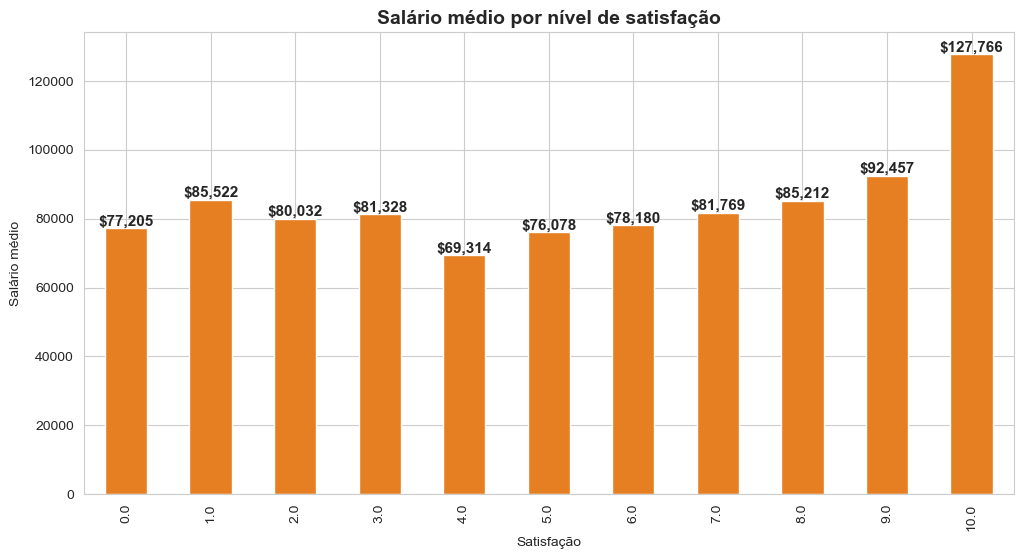

In [40]:
# Analisando a média de remuneração pelo nível de satisfação

# Filtrar apenas valores não nulos de salário e Satisfação no trabalho
df_clean_salary_jobsat = df[['ConvertedCompYearly', 'JobSat']].dropna()
df_media = df_clean_salary_jobsat.groupby('JobSat')['ConvertedCompYearly'].mean()

# Inserindo o gráfico de barras
plt.figure(figsize=(12,6))
ax = df_media.plot(kind='bar', color='#e67e22')
plt.title('Salário médio por nível de satisfação', fontsize=14, weight='bold')
plt.ylabel('Salário médio')
plt.xlabel('Satisfação')

# Inserir os valores em cima das barras
for i, v in enumerate(df_media):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom',fontsize=11, weight='bold')

# Exibindo o gráfico
plt.show()